# CAA Project 2 - Deep Learning Approaches for Pneumonia Detection: Multi-Scale Analysis with Explainable AI

**Exploratory Data Analysis (EDA) Notebook**

- This notebook now analyzes the PneumoniaMNIST dataset across multiple resolutions: 28x28, 64x64, 128x128, and 224x224 pixels.
- Each resolution maintains the same dataset splits and label distributions, but provides different levels of detail for the chest X-ray images.

Authors:
- Maria Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [1]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules
from utils.data_utils import create_augmentation_pipeline, apply_augmentation

# Import math and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import deep learning libraries
import tensorflow as tf

2025-06-22 14:17:23.912006: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-22 14:17:23.934919: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750598243.960793  128536 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750598243.967929  128536 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-22 14:17:23.993973: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

# Data Loading

- NOTE: We could be using the direct code by importing the official medmnist library, but it installs PyTorch dependencies and we intend to use Tensorflow.

Resolution 28x28:
  Train - images: (4708, 28, 28), labels: (4708, 1)
  Test  - images: (624, 28, 28), labels: (624, 1)
  Val   - images: (524, 28, 28), labels: (524, 1)
  Distribution of labels:
    Training set   - Normal: 1214, Pneumonia: 3494
    Testing set    - Normal: 234, Pneumonia: 390
    Validation set - Normal: 135, Pneumonia: 389

Resolution 64x64:
  Train - images: (4708, 64, 64), labels: (4708, 1)
  Test  - images: (624, 64, 64), labels: (624, 1)
  Val   - images: (524, 64, 64), labels: (524, 1)
  Distribution of labels:
    Training set   - Normal: 1214, Pneumonia: 3494
    Testing set    - Normal: 234, Pneumonia: 390
    Validation set - Normal: 135, Pneumonia: 389

Resolution 128x128:
  Train - images: (4708, 128, 128), labels: (4708, 1)
  Test  - images: (624, 128, 128), labels: (624, 1)
  Val   - images: (524, 128, 128), labels: (524, 1)
  Distribution of labels:
    Training set   - Normal: 1214, Pneumonia: 3494
    Testing set    - Normal: 234, Pneumonia: 390
    

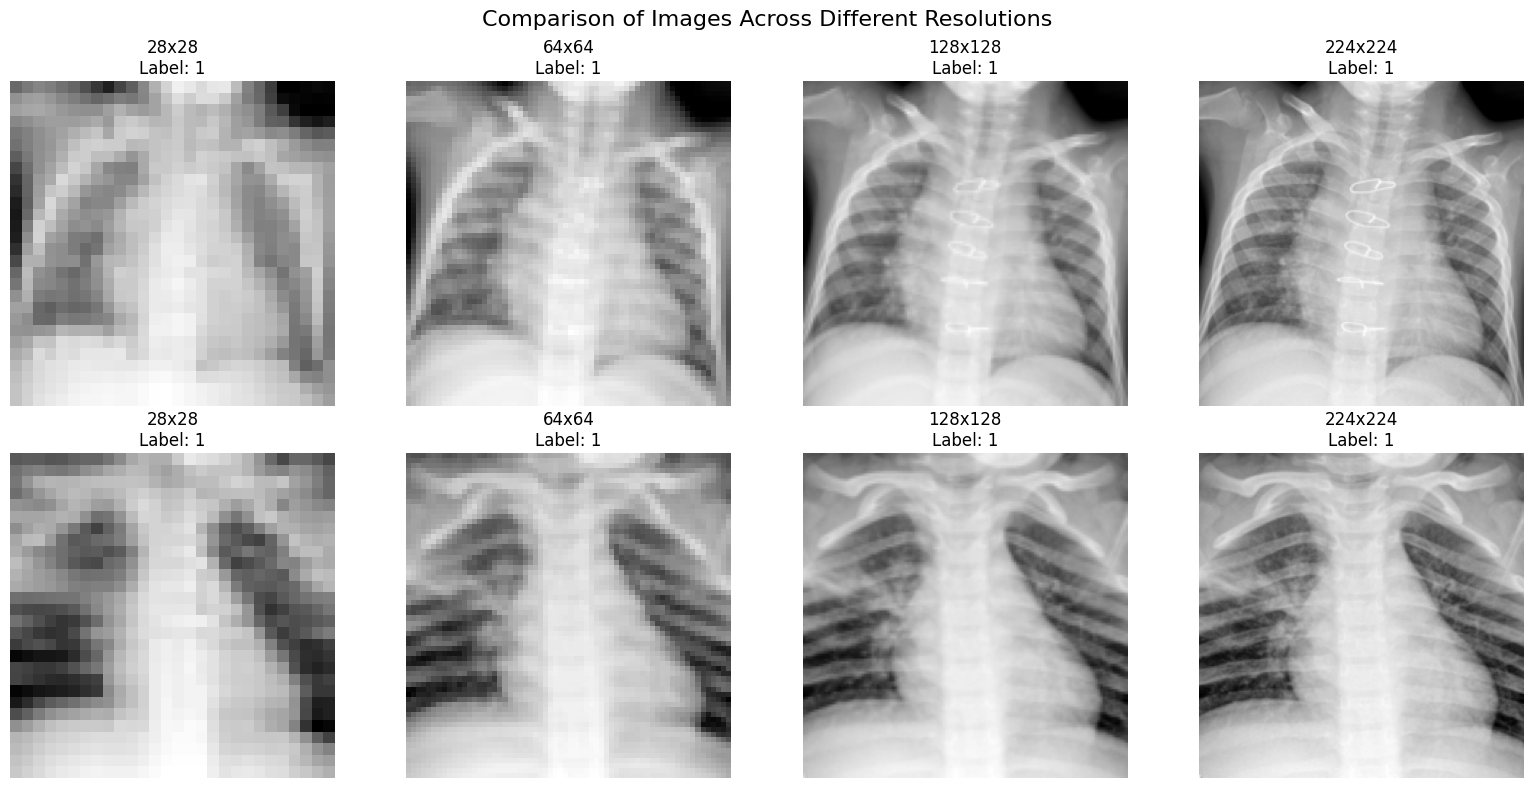


Sample images at 28x28 resolution:


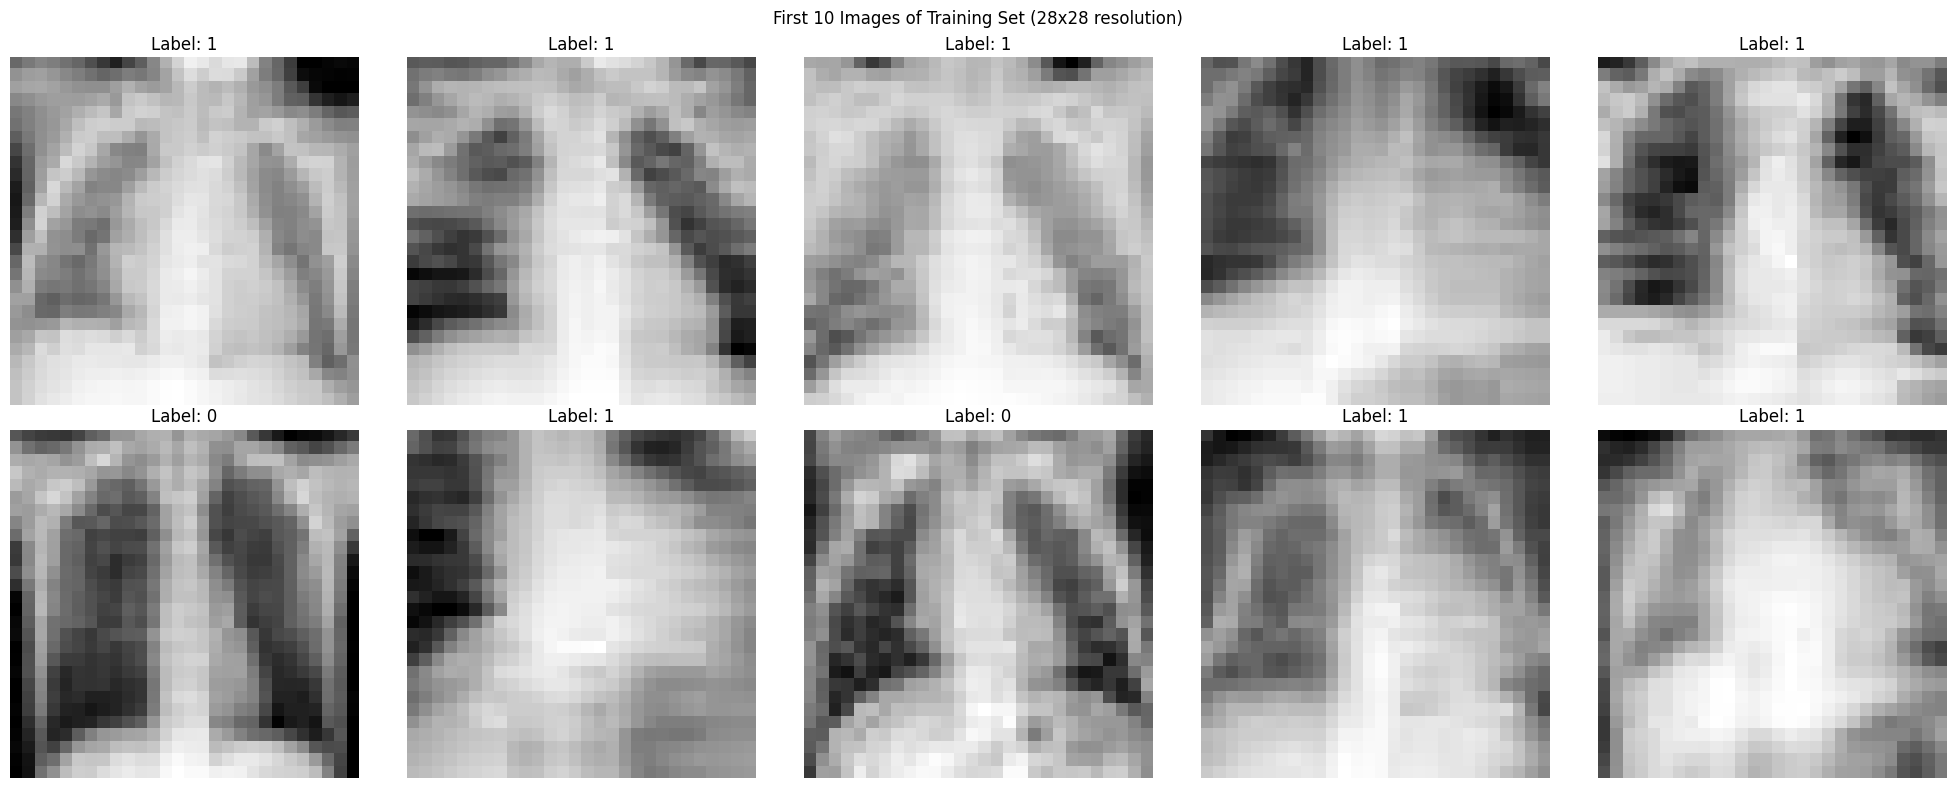


Sample images at 64x64 resolution:


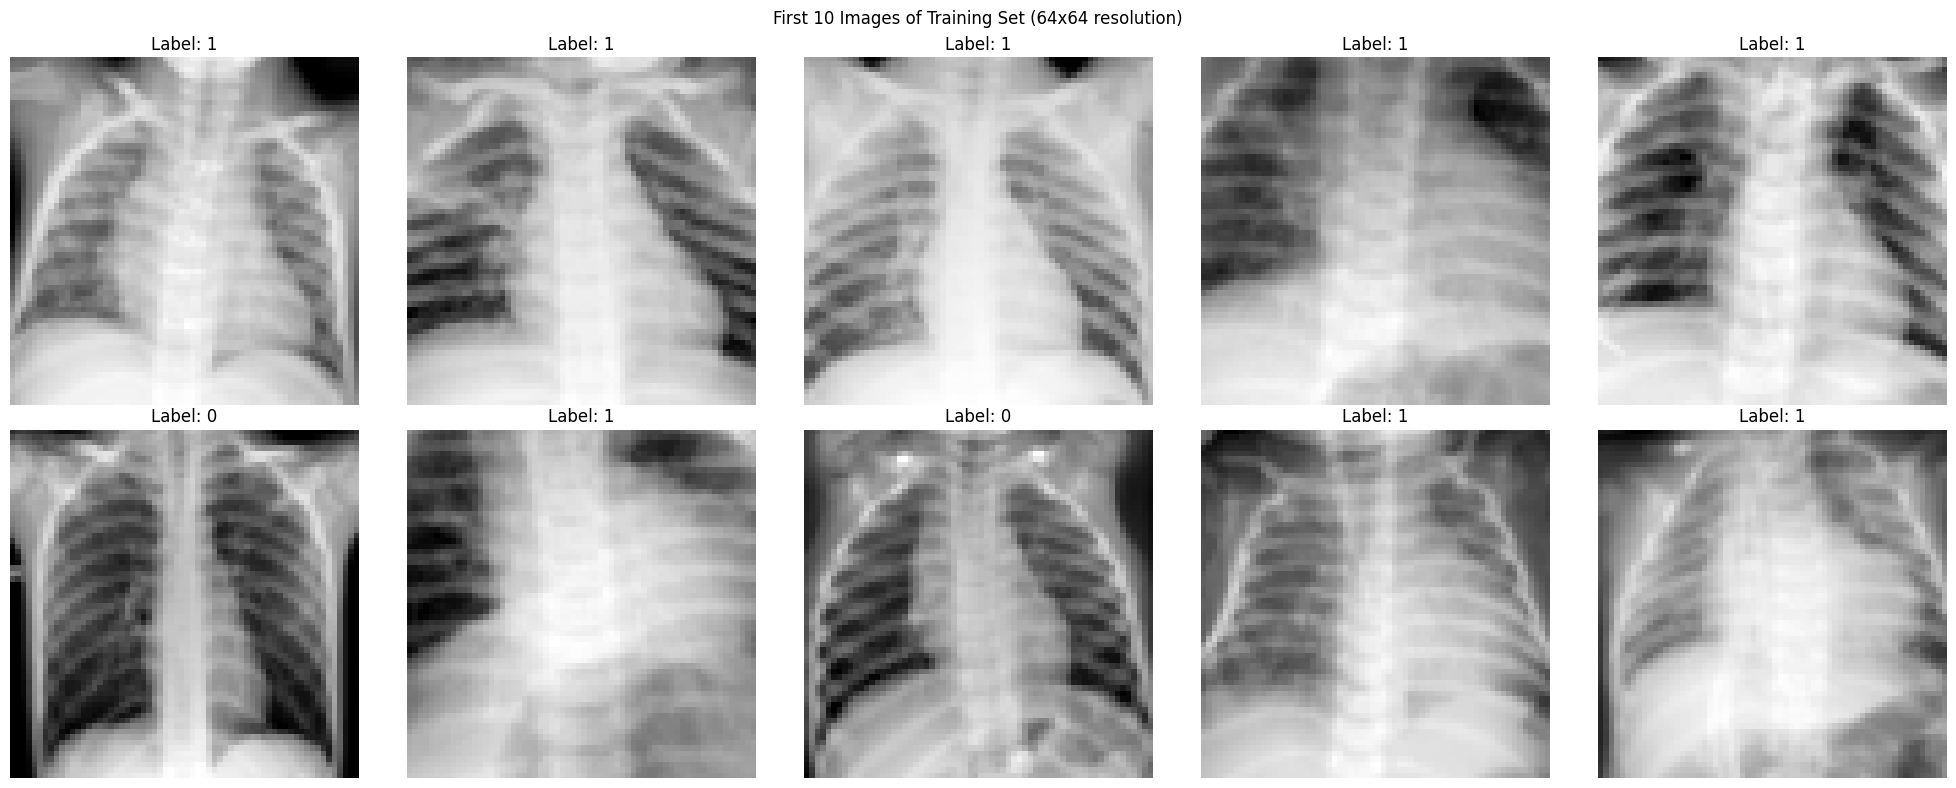


Sample images at 128x128 resolution:


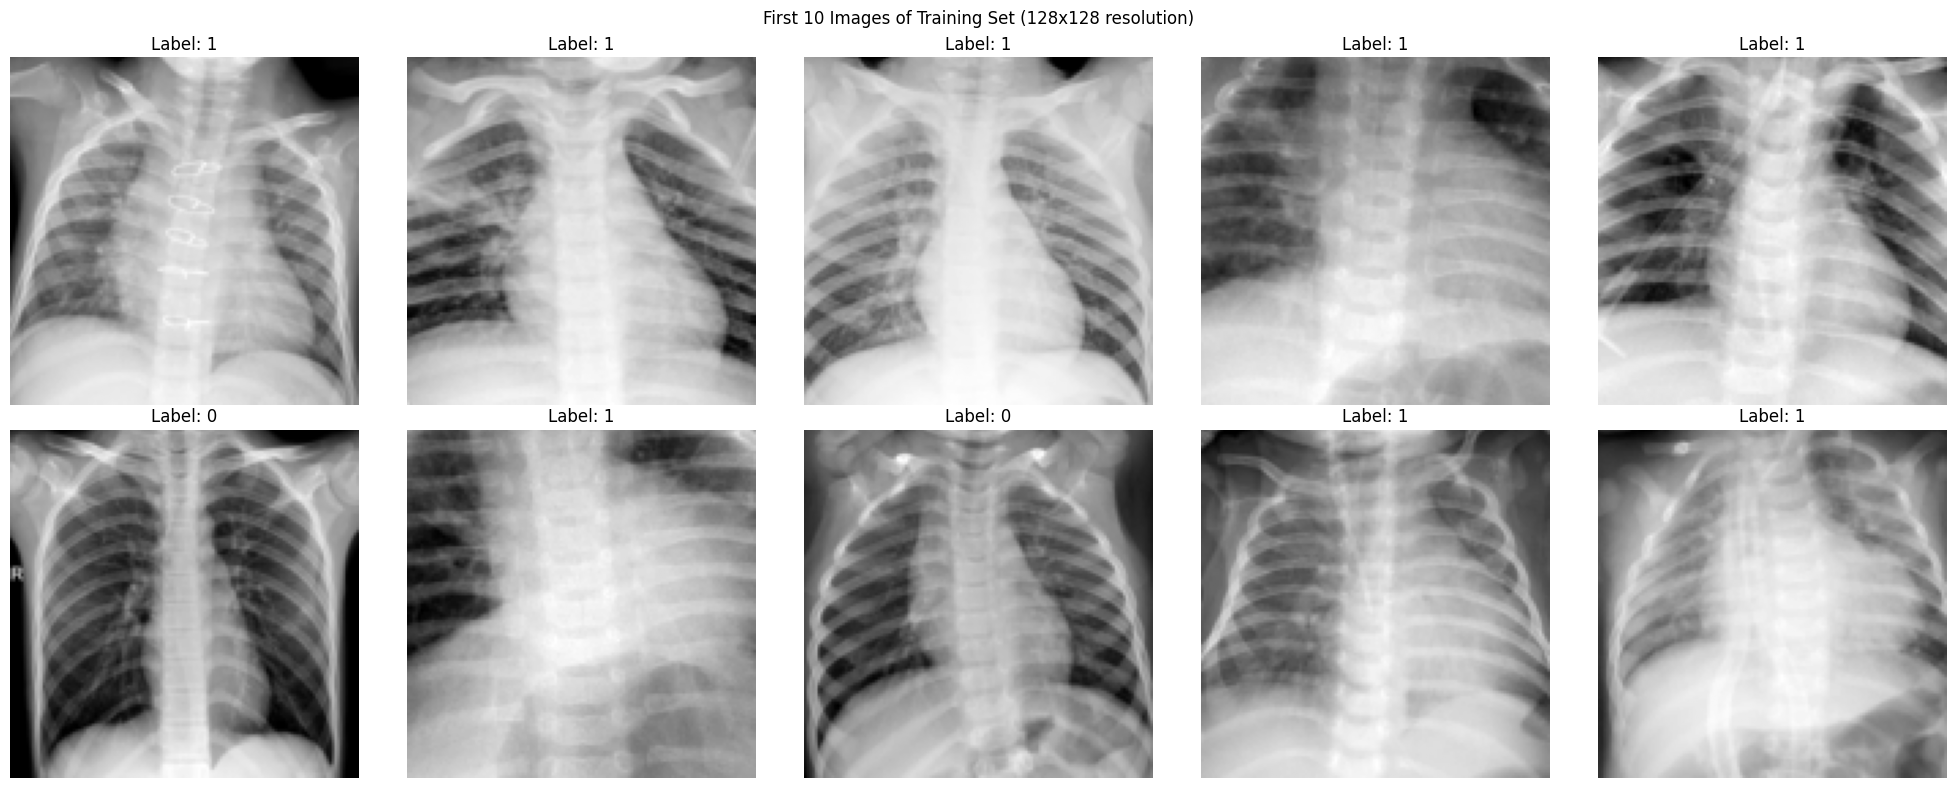


Sample images at 224x224 resolution:


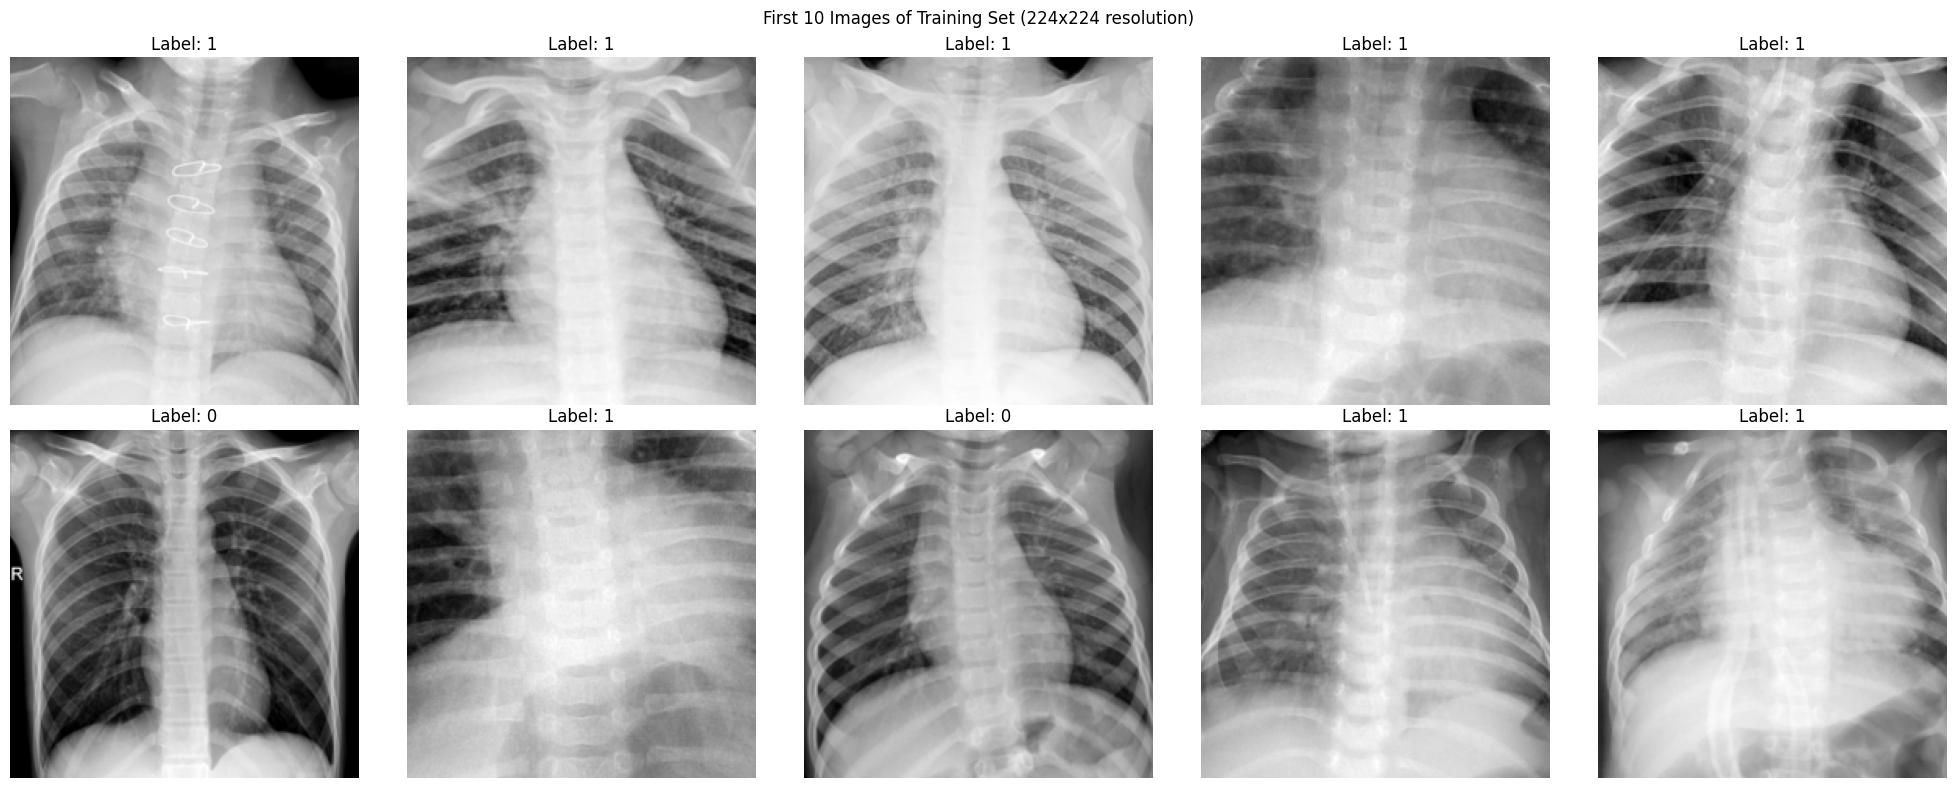

In [2]:
# Define resolutions available
resolutions = [28, 64, 128, 224]

# Dictionary to store data for each resolution
data_by_resolution = {}

for res in resolutions:
    data_path = f"../data/pneumoniamnist_{res}/"
    
    # Load the files for the training, testing and validation sets
    train_images = np.load(f"{data_path}train_images.npy")
    train_labels = np.load(f"{data_path}train_labels.npy")
    test_images = np.load(f"{data_path}test_images.npy")
    test_labels = np.load(f"{data_path}test_labels.npy")
    val_images = np.load(f"{data_path}val_images.npy")
    val_labels = np.load(f"{data_path}val_labels.npy")
    
    # Store in dictionary
    data_by_resolution[res] = {
        'train_images': train_images,
        'train_labels': train_labels,
        'test_images': test_images,
        'test_labels': test_labels,
        'val_images': val_images,
        'val_labels': val_labels
    }
    
    # Print the shapes of the data for this resolution
    print(f"Resolution {res}x{res}:")
    print(f"  Train - images: {train_images.shape}, labels: {train_labels.shape}")
    print(f"  Test  - images: {test_images.shape}, labels: {test_labels.shape}")
    print(f"  Val   - images: {val_images.shape}, labels: {val_labels.shape}")
    
    # Check the unique labels in all sets for this resolution
    unique_train, counts_train = np.unique(train_labels, return_counts=True)
    unique_test, counts_test = np.unique(test_labels, return_counts=True)
    unique_val, counts_val = np.unique(val_labels, return_counts=True)
    
    print(f"  Distribution of labels:")
    print(f"    Training set   - Normal: {counts_train[0]}, Pneumonia: {counts_train[1]}")
    print(f"    Testing set    - Normal: {counts_test[0]}, Pneumonia: {counts_test[1]}")
    print(f"    Validation set - Normal: {counts_val[0]}, Pneumonia: {counts_val[1]}")
    print()

# Use 28x28 resolution as reference for the overall statistics (all resolutions should have same label distribution)
ref_data = data_by_resolution[28]
train_images = ref_data['train_images']
train_labels = ref_data['train_labels']
test_images = ref_data['test_images']
test_labels = ref_data['test_labels']
val_images = ref_data['val_images']
val_labels = ref_data['val_labels']

unique_train, counts_train = np.unique(train_labels, return_counts=True)
unique_test, counts_test = np.unique(test_labels, return_counts=True)
unique_val, counts_val = np.unique(val_labels, return_counts=True)

# Create a comparison view: 2 images across all 4 resolutions
print("Comparison of the same images across different resolutions:")
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

for row in range(2):
    for col, res in enumerate(resolutions):
        img = data_by_resolution[res]['train_images'][row]
        label = data_by_resolution[res]['train_labels'][row]
        
        axs[row, col].imshow(img, cmap='gray')
        axs[row, col].set_title(f'{res}x{res}\nLabel: {label[0] if label.ndim > 0 else label}')
        axs[row, col].axis('off')

plt.suptitle("Comparison of Images Across Different Resolutions", fontsize=16)
plt.tight_layout()
plt.show()

# Show sample images for each resolution separately
for res in resolutions:
    current_data = data_by_resolution[res]
    
    print(f"\nSample images at {res}x{res} resolution:")
    num_images = 10
    fig, axs = plt.subplots(2, 5, figsize=(20, 8))
    
    for i in range(2):
        for j in range(5):
            idx = i * 5 + j
            img = current_data['train_images'][idx]
            label = current_data['train_labels'][idx]
            
            axs[i,j].imshow(img, cmap='gray')
            axs[i,j].set_title(f'Label: {label[0] if label.ndim > 0 else label}')
            axs[i,j].axis('off')
    
    plt.suptitle(f"First {num_images} Images of Training Set ({res}x{res} resolution)")
    plt.tight_layout()
    plt.show()

# Class Distribution

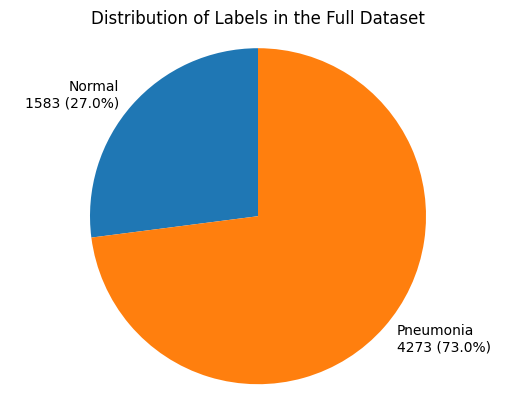


Distribution of labels in the full dataset:

           Count  Percentage
Label                       
Normal      1583   27.032104
Pneumonia   4273   72.967896


In [3]:
# Pie chart with the distribution of labels overall
labels = ['Normal', 'Pneumonia']
sizes = [counts_train[0] + counts_test[0] + counts_val[0], counts_train[1] + counts_test[1] + counts_val[1]]

# Calculate percentages and create custom labels
total = sum(sizes)
percentages = [s/total*100 for s in sizes]
labels = [f'{labels[i]}\n{sizes[i]} ({percentages[i]:.1f}%)' for i in range(len(labels))]

fig1, ax1 = plt.subplots()
ax1.pie(sizes, labels=labels, autopct='', startangle=90)
ax1.axis('equal')
plt.title("Distribution of Labels in the Full Dataset")
plt.show()

# Table with the distribution of labels in the full dataset
data = {'Label': ['Normal', 'Pneumonia'], 
        'Count': [sizes[0], sizes[1]], 
        'Percentage': [percentages[0], percentages[1]]}
df = pd.DataFrame(data)
df.set_index('Label', inplace=True)
print("\nDistribution of labels in the full dataset:\n")
print(df)

# Data Splitting
- The data was already pre-split by the authors, but it is still useful to verify the amount of examples in each set.

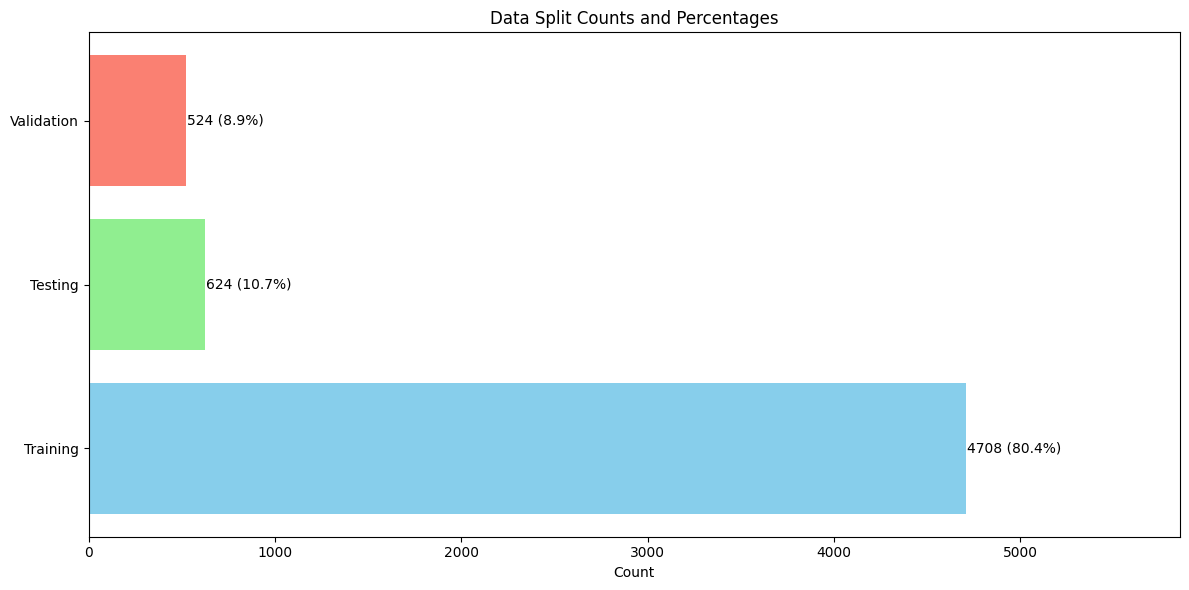


Data Split Counts and Percentages:

            Count Percentage
Set                         
Training     4708      80.4%
Testing       624      10.7%
Validation    524       8.9%


In [4]:
# Calculate totals for each dataset
total_train = counts_train[0] + counts_train[1]
total_test  = counts_test[0] + counts_test[1]
total_val   = counts_val[0] + counts_val[1]
total_all   = total_train + total_test + total_val

# Labels and counts for each split
split_labels = ['Training', 'Testing', 'Validation']
split_counts = [total_train, total_test, total_val]

colors = ['skyblue', 'lightgreen', 'salmon']

# Horizontal Bar Chart (Sidebar) for Data Split
plt.figure(figsize=(12,6))
bars = plt.barh(split_labels, split_counts, color=colors)
for bar, count in zip(bars, split_counts):
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
            f'{count} ({count/total_all*100:.1f}%)', va='center', fontsize=10)
plt.xlim(0, total_all)
plt.title('Data Split Counts and Percentages')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Table with the data split counts and percentages
data = {'Set': split_labels,
        'Count': split_counts,
        'Percentage': [f'{c/total_all*100:.1f}%' for c in split_counts]}
df = pd.DataFrame(data)
df.set_index('Set', inplace=True)
print("\nData Split Counts and Percentages:\n")
print(df)

# Class Distribution across Splits (Sets)

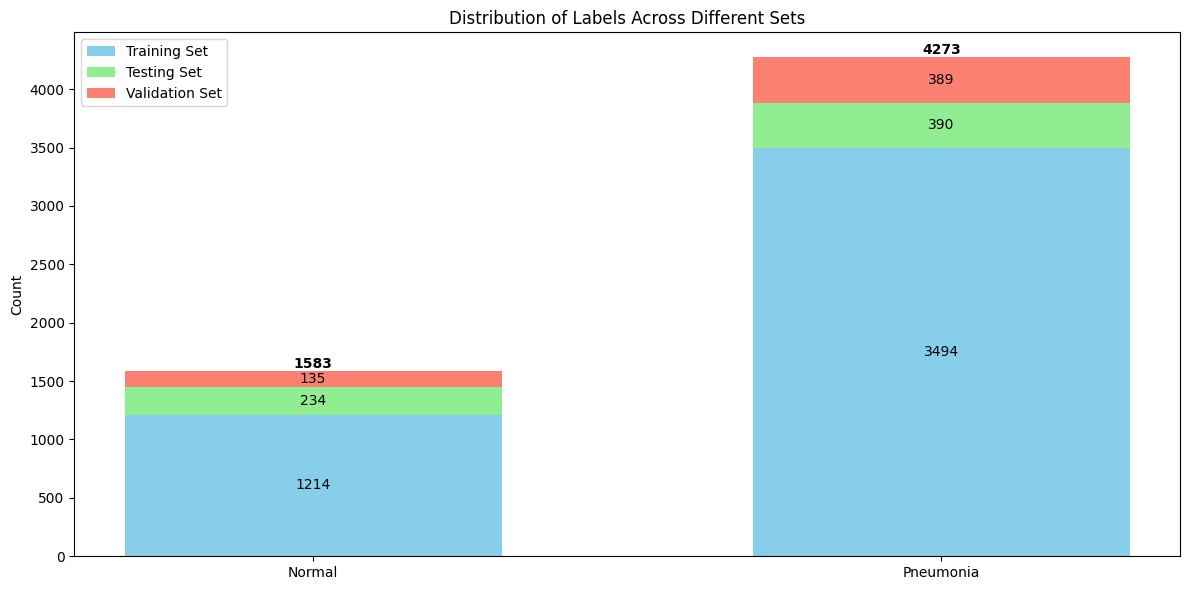


Distribution of labels accross different sets:

            Normal  Pneumonia
Set                          
Training      1214       3494
Testing        234        390
Validation     135        389
TOTAL         1583       4273


In [5]:
# Create stacked bar chart with individual segment annotations
width = 0.6
labels = ['Normal', 'Pneumonia']

plt.figure(figsize=(12, 6))

# Calculate totals for each label
total_normal = counts_train[0] + counts_test[0] + counts_val[0]
total_pneumonia = counts_train[1] + counts_test[1] + counts_val[1]

# Plot stacked bars for each set
plt.bar(labels, [counts_train[0], counts_train[1]], width,
        label='Training Set', color='skyblue')
plt.bar(labels, [counts_test[0], counts_test[1]], width,
        bottom=[counts_train[0], counts_train[1]],
        label='Testing Set', color='lightgreen')
plt.bar(labels, [counts_val[0], counts_val[1]], width,
        bottom=[counts_train[0] + counts_test[0], counts_train[1] + counts_test[1]],
        label='Validation Set', color='salmon')

# Annotate each segment with its value
for i, label in enumerate(labels):
    # Training set annotation
    train_val = counts_train[i]
    plt.text(i, train_val/2, str(train_val),
            ha='center', va='center', color='black')
    
    # Testing set annotation
    test_val = counts_test[i]
    plt.text(i, counts_train[i] + test_val/2, str(test_val),
            ha='center', va='center', color='black')
    
    # Validation set annotation
    val_val = counts_val[i]
    plt.text(i, counts_train[i] + counts_test[i] + val_val/2, str(val_val),
            ha='center', va='center', color='black')
    
    # Add the total on top of the bar
    total = total_normal if i == 0 else total_pneumonia
    plt.text(i, total, str(total), ha='center', va='bottom', fontweight='bold')

plt.ylabel('Count')
plt.title('Distribution of Labels Across Different Sets')
plt.legend()
plt.tight_layout()
plt.show()

# Table with the distribution of labels accross different sets
data = {'Set': ['Training', 'Testing', 'Validation', 'TOTAL'],
        'Normal': [counts_train[0], counts_test[0], counts_val[0], total_normal],
        'Pneumonia': [counts_train[1], counts_test[1], counts_val[1], total_pneumonia]}
df = pd.DataFrame(data)
df.set_index('Set', inplace=True)
print("\nDistribution of labels accross different sets:\n")
print(df)

# Data Augmentation Across Resolutions

I0000 00:00:1750598254.007029  128536 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2787 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 7.5



Data Augmentation Examples at 28x28 resolution:


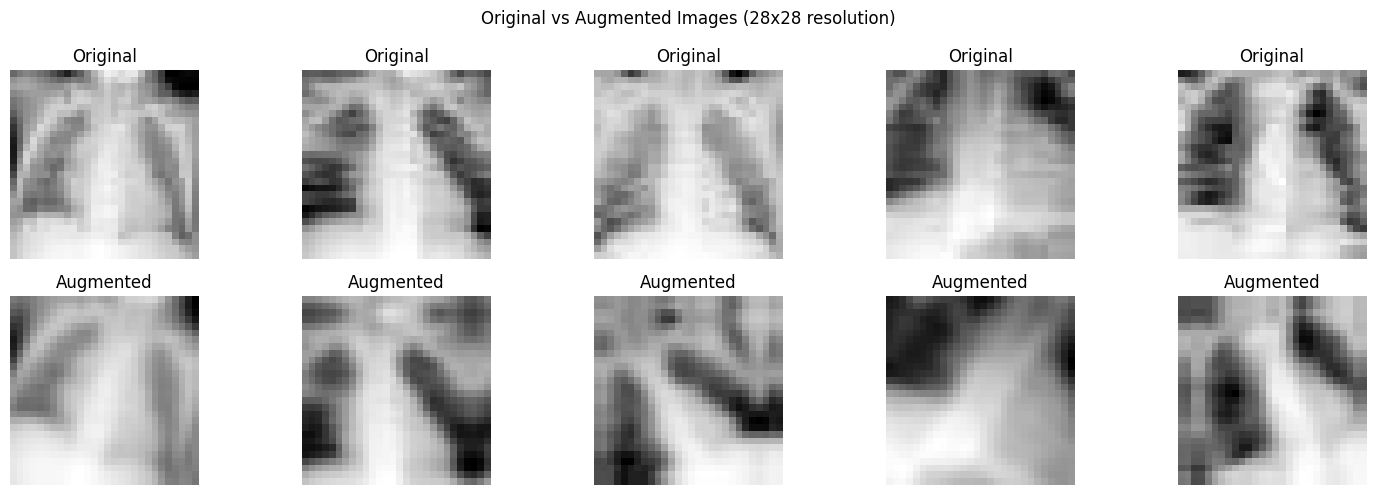

  Augmented batch shape at 28x28: (32, 28, 28, 1)
  Augmented labels shape: (32, 2)

Data Augmentation Examples at 64x64 resolution:


2025-06-22 14:17:38.863590: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


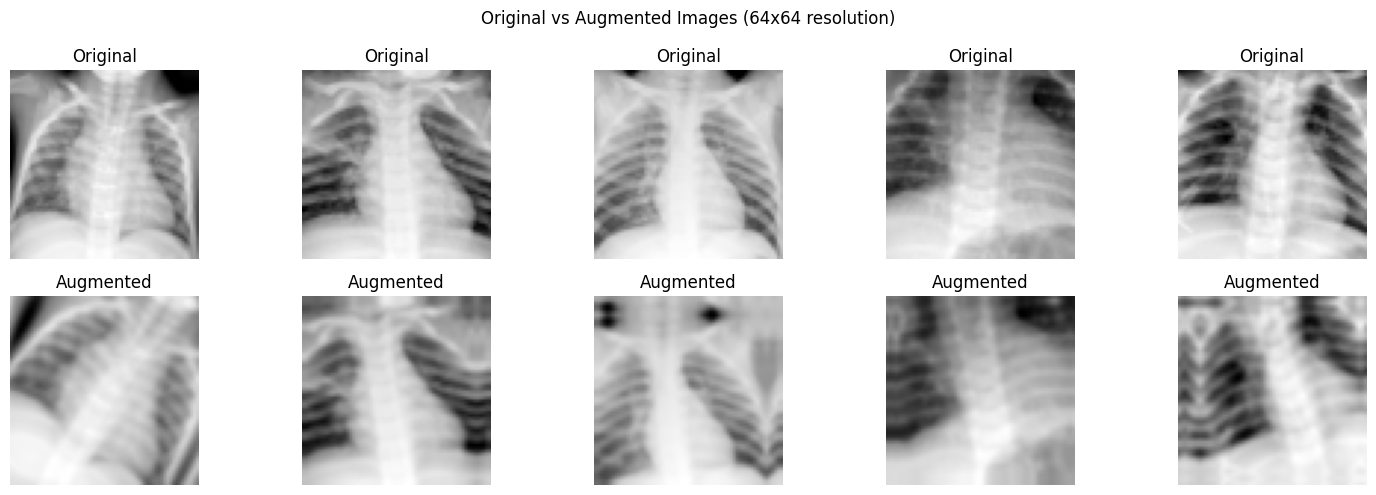

  Augmented batch shape at 64x64: (32, 64, 64, 1)
  Augmented labels shape: (32, 2)


2025-06-22 14:17:40.508460: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Data Augmentation Examples at 128x128 resolution:


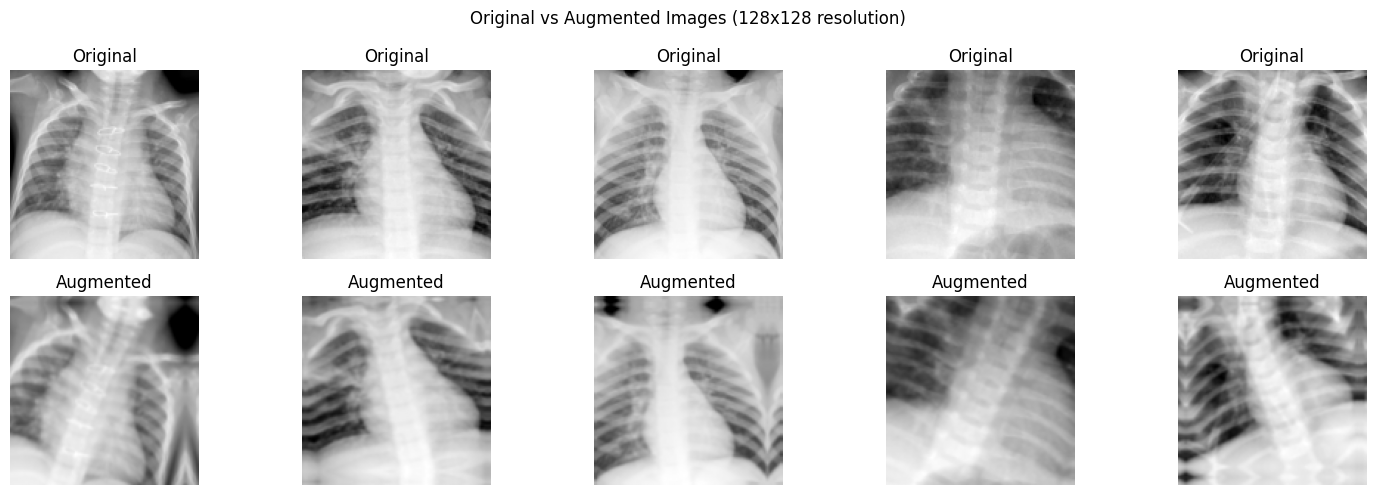

  Augmented batch shape at 128x128: (32, 128, 128, 1)
  Augmented labels shape: (32, 2)

Data Augmentation Examples at 224x224 resolution:


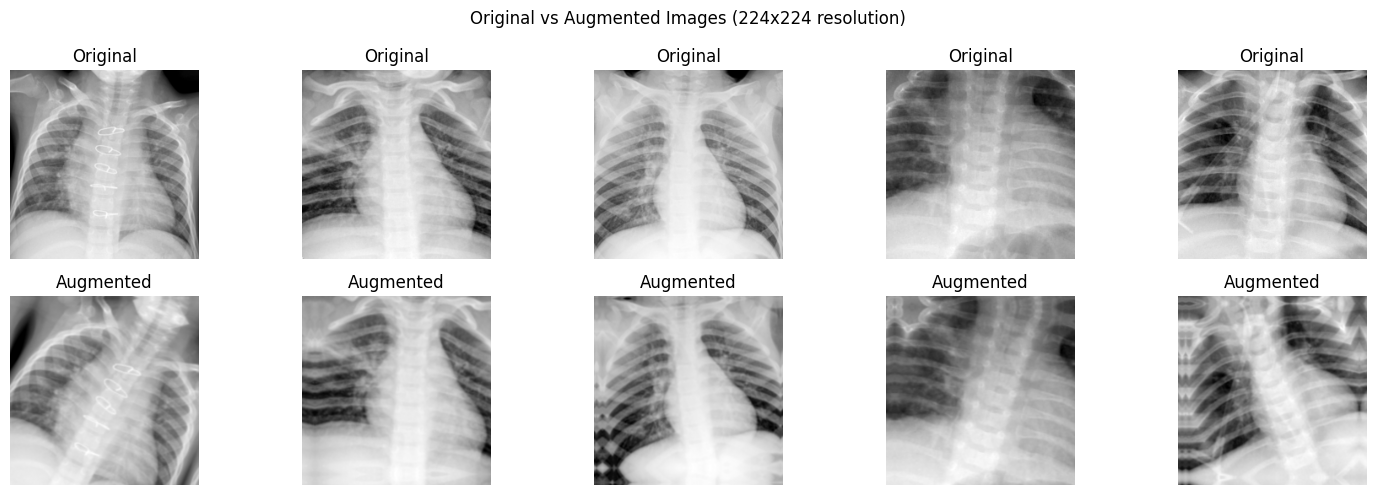

  Augmented batch shape at 224x224: (32, 224, 224, 1)
  Augmented labels shape: (32, 2)

Comparison of augmentation across different resolutions:


2025-06-22 14:17:47.813799: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


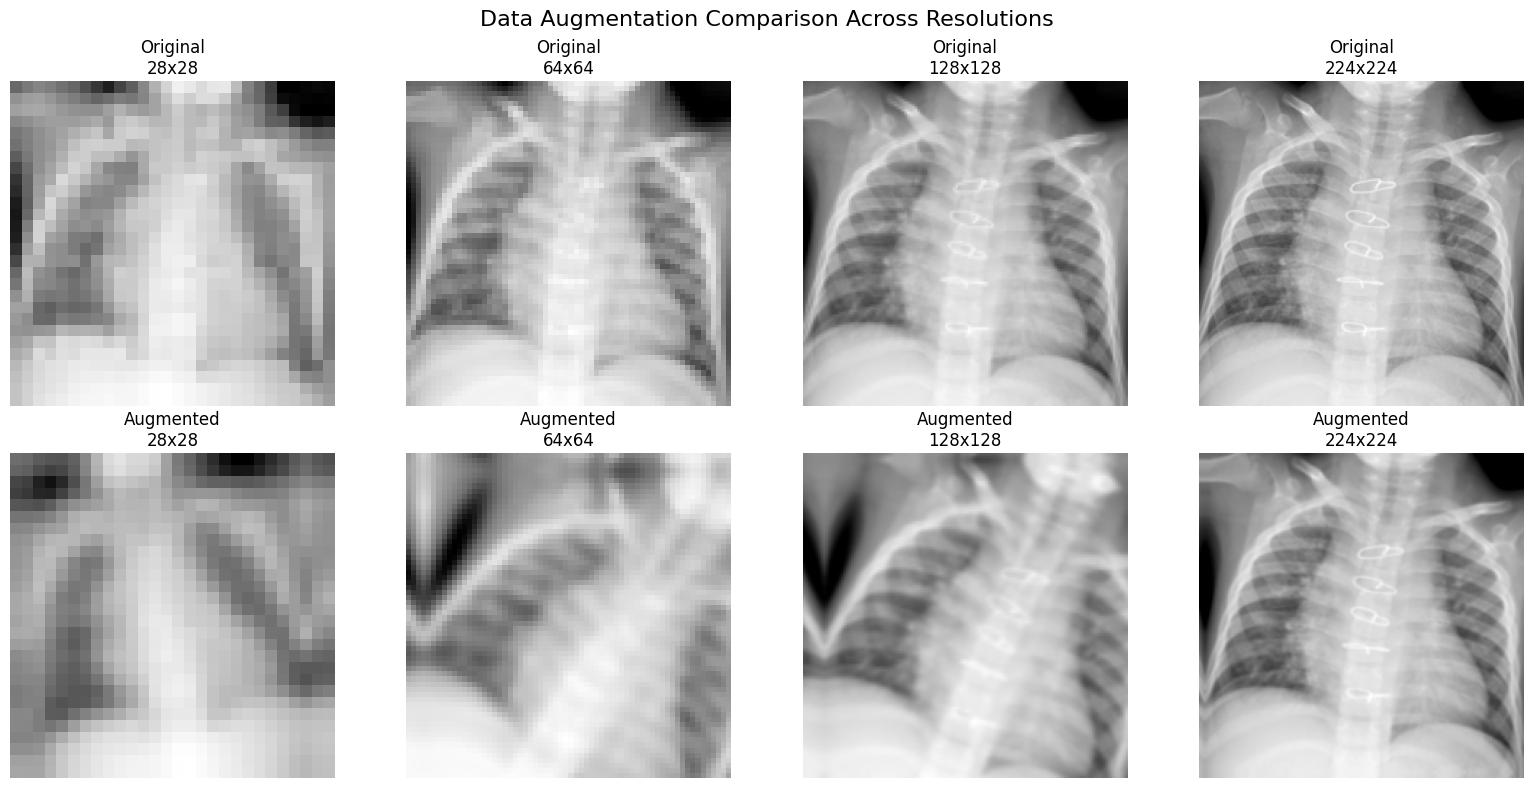

In [6]:
# Preprocess images (reshape and normalize)
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
train_images = train_images.astype('float32') / 255.0
train_labels = tf.keras.utils.to_categorical(train_labels, 2)

# Create the augmentation pipeline
augmentation_pipeline = create_augmentation_pipeline()

# Show augmentation for each resolution
for res in resolutions:
    current_data = data_by_resolution[res]
    
    # Preprocess images for this resolution (reshape and normalize)
    processed_images = current_data['train_images'].reshape(
        current_data['train_images'].shape[0], res, res, 1
    ).astype('float32') / 255.0
    
    processed_labels = tf.keras.utils.to_categorical(current_data['train_labels'], 2)
    
    print(f"\nData Augmentation Examples at {res}x{res} resolution:")
    
    # Visualize augmented images for this resolution
    plt.figure(figsize=(15, 5))
    for i in range(5):
        # Select an original image
        original_image = processed_images[i]
        
        plt.subplot(2, 5, i+1)
        plt.imshow(original_image.squeeze(), cmap='gray')
        plt.title('Original')
        plt.axis('off')
        
        plt.subplot(2, 5, i+6)
        # Apply augmentation multiple times to show variations
        augmented_image = augmentation_pipeline(tf.expand_dims(original_image, 0), training=True)
        plt.imshow(augmented_image[0].numpy().squeeze(), cmap='gray')
        plt.title('Augmented')
        plt.axis('off')

    plt.suptitle(f'Original vs Augmented Images ({res}x{res} resolution)')
    plt.tight_layout()
    plt.show()
    
    # Test the augmented dataset creation for this resolution
    augmented_dataset = apply_augmentation(processed_images, processed_labels, batch_size=32)
    
    # Iterate through the augmented dataset to verify
    for images, labels in augmented_dataset.take(1):
        print(f"  Augmented batch shape at {res}x{res}: {images.shape}")
        print(f"  Augmented labels shape: {labels.shape}")

# Create a comprehensive comparison: same image with augmentation across all resolutions
print("\nComparison of augmentation across different resolutions:")
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

# Select one image for comparison
selected_idx = 0

for col, res in enumerate(resolutions):
    current_data = data_by_resolution[res]
    
    # Preprocess the selected image
    processed_image = current_data['train_images'][selected_idx].reshape(1, res, res, 1).astype('float32') / 255.0
    
    # Original image
    axs[0, col].imshow(processed_image[0].squeeze(), cmap='gray')
    axs[0, col].set_title(f'Original\n{res}x{res}')
    axs[0, col].axis('off')
    
    # Augmented image
    augmented_image = augmentation_pipeline(processed_image, training=True)
    axs[1, col].imshow(augmented_image[0].numpy().squeeze(), cmap='gray')
    axs[1, col].set_title(f'Augmented\n{res}x{res}')
    axs[1, col].axis('off')

plt.suptitle("Data Augmentation Comparison Across Resolutions", fontsize=16)
plt.tight_layout()
plt.show()